# 02 · Descriptive Analysis

Visualize the raw data and show how strong (and misleading) the cross-sectional association is.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

panel  = pd.read_parquet(DATA_DIR / "ship_month_panel.parquet")
events = pd.read_csv(DATA_DIR / "category_change_events.csv", parse_dates=["event_month"])

print(f"Panel: {panel.shape}  |  Events: {len(events)}")

Panel: (38400, 15)  |  Events: 144


## Figure 1 · Cross-sectional scatter (ship averages)

This is the picture that *looks* compelling but is almost entirely selection.

/var/folders/fz/tv4zf2qx03x5ymbgmc6hccl00000gn/T/ipykernel_74236/2589646948.py:41: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/fz/tv4zf2qx03x5ymbgmc6hccl00000gn/T/ipykernel_74236/2589646948.py:41: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/fz/tv4zf2qx03x5ymbgmc6hccl00000gn/T/ipykernel_74236/2589646948.py:42: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig(OUT_DIR / "02a_cross_sectional_scatter.png", bbox_inches="tight")
/var/folders/fz/tv4zf2qx03x5ymbgmc6hccl00000gn/T/ipykernel_74236/2589646948.py:42: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig(OUT_DIR / "02a_cross_sectional_scatter.png", bbox_inches="tight")


/Users/jacobkylerosen/personal-github/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jacobkylerosen/personal-github/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


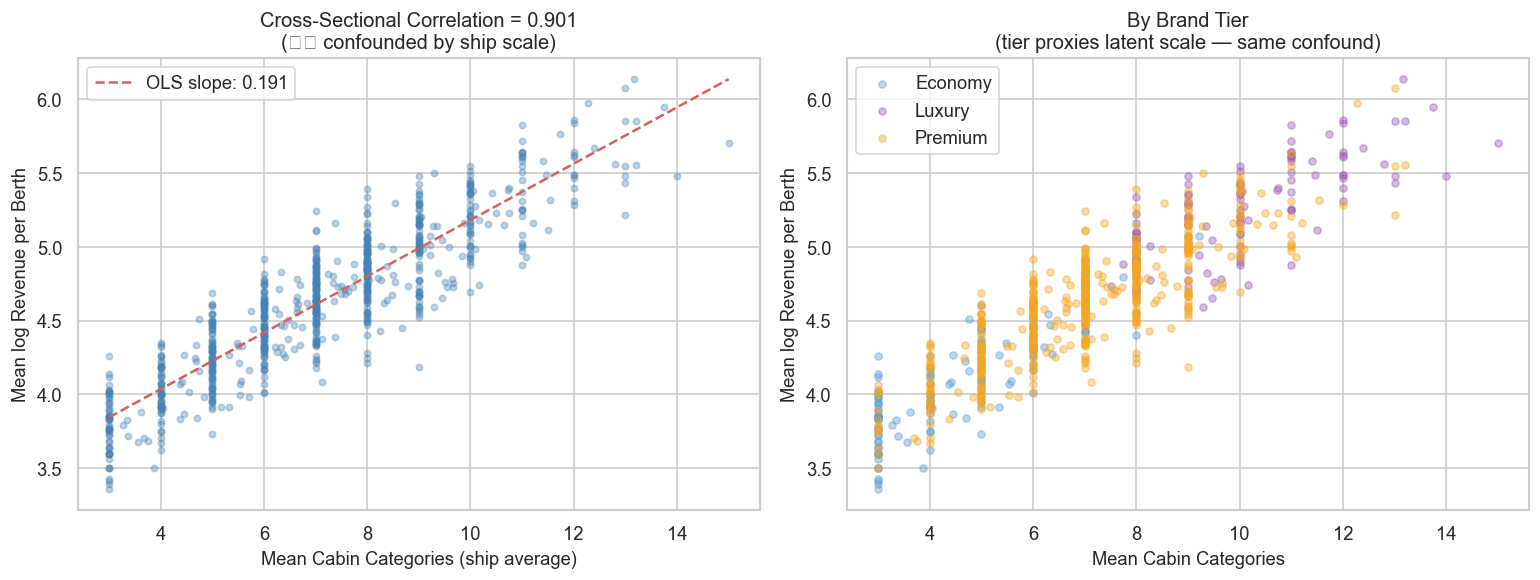

Cross-sectional corr = 0.901
True causal β        = 0.06  per category
Overstatement ratio  ≈ 3.2×


In [2]:
ship_means = (
    panel.groupby(["ship_id", "brand_tier"])
    [["cabin_category_count", "log_revenue_per_berth", "berth_capacity"]]
    .mean()
    .reset_index()
)

xs_corr = ship_means["cabin_category_count"].corr(ship_means["log_revenue_per_berth"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: raw
axes[0].scatter(
    ship_means["cabin_category_count"],
    ship_means["log_revenue_per_berth"],
    alpha=0.35, s=14, c="steelblue"
)
# OLS fit line
m, b = np.polyfit(ship_means["cabin_category_count"], ship_means["log_revenue_per_berth"], 1)
x_range = np.linspace(ship_means["cabin_category_count"].min(),
                       ship_means["cabin_category_count"].max(), 100)
axes[0].plot(x_range, m * x_range + b, "r--", lw=1.5, label=f"OLS slope: {m:.3f}")
axes[0].set_xlabel("Mean Cabin Categories (ship average)", fontsize=11)
axes[0].set_ylabel("Mean log Revenue per Berth", fontsize=11)
axes[0].set_title(f"Cross-Sectional Correlation = {xs_corr:.3f}\n(⚠️ confounded by ship scale)")
axes[0].legend()

# Panel B: by brand tier
palette = {"economy": "#5C9BD6", "premium": "#F5A623", "luxury": "#9B59B6"}
for tier, grp in ship_means.groupby("brand_tier"):
    axes[1].scatter(
        grp["cabin_category_count"],
        grp["log_revenue_per_berth"],
        alpha=0.4, s=18, label=tier.capitalize(), c=palette[tier]
    )
axes[1].set_xlabel("Mean Cabin Categories", fontsize=11)
axes[1].set_ylabel("Mean log Revenue per Berth", fontsize=11)
axes[1].set_title("By Brand Tier\n(tier proxies latent scale — same confound)")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "02a_cross_sectional_scatter.png", bbox_inches="tight")
plt.show()
print(f"Cross-sectional corr = {xs_corr:.3f}")
print(f"True causal β        = 0.06  per category")
print(f"Overstatement ratio  ≈ {m/0.06:.1f}×")

## Figure 2 · Refit event timeline

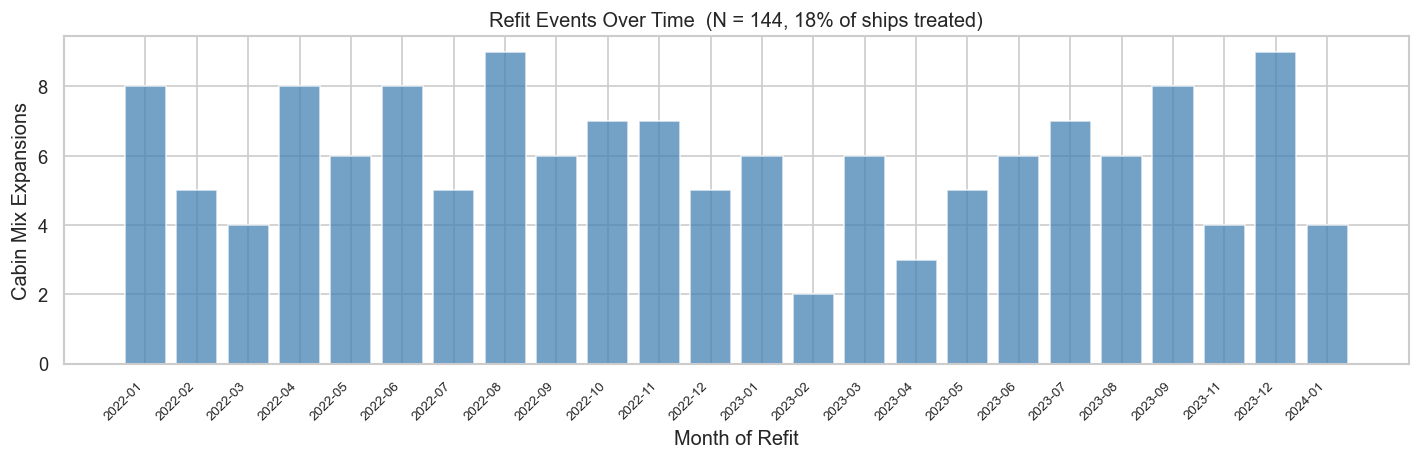

In [3]:
event_counts = (
    events.groupby(events["event_month"].dt.to_period("M"))
    .size()
    .reset_index(name="count")
)
event_counts["month_str"] = event_counts["event_month"].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(event_counts["month_str"], event_counts["count"], color="steelblue", alpha=0.75)
ax.set_xlabel("Month of Refit")
ax.set_ylabel("Cabin Mix Expansions")
ax.set_title(f"Refit Events Over Time  (N = {len(events)}, {len(events)/800*100:.0f}% of ships treated)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "02b_event_timeline.png", bbox_inches="tight")
plt.show()

## Figure 3 · Revenue by treatment status (raw pre/post)

This is *not* a causal estimate — just illustrating the raw pattern.

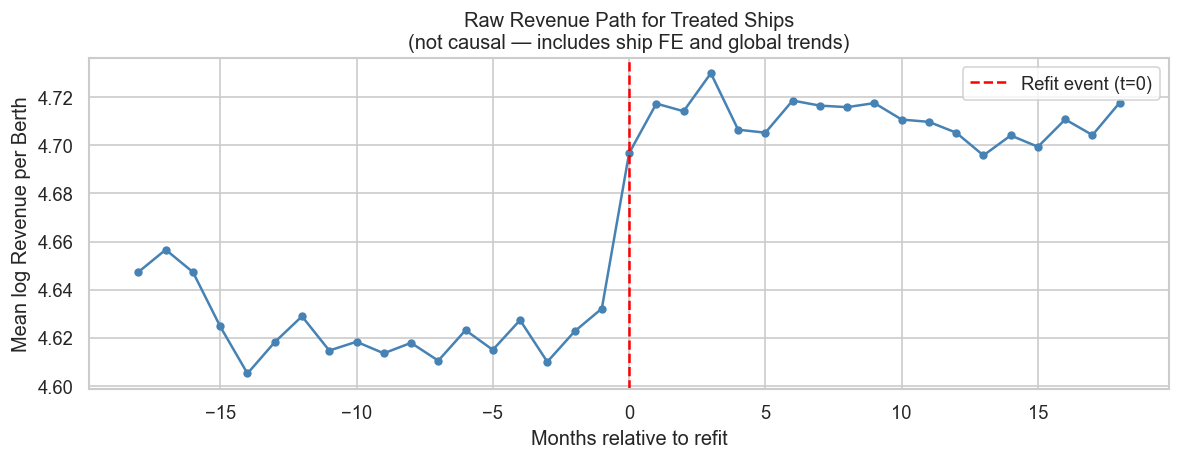

Note: This raw pattern conflates ship FE, time trends, and causal effect.
See notebooks 04 and 08 for the causal estimates.


In [4]:
panel_with_event = panel.merge(
    events[["ship_id", "event_month_idx"]], on="ship_id", how="left"
)
panel_with_event["rel_month"] = (
    panel_with_event["months_since_category_change"]
)

# Average log_rpb by relative month, for treated ships only
treated_ts = (
    panel_with_event[panel_with_event["had_category_change"]]
    .groupby("rel_month")["log_revenue_per_berth"]
    .mean()
    .reset_index()
)
# Clip to ±18 months
treated_ts = treated_ts[treated_ts["rel_month"].between(-18, 18)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(treated_ts["rel_month"], treated_ts["log_revenue_per_berth"],
        marker="o", ms=4, lw=1.5, c="steelblue")
ax.axvline(0, color="red", ls="--", lw=1.5, label="Refit event (t=0)")
ax.set_xlabel("Months relative to refit")
ax.set_ylabel("Mean log Revenue per Berth")
ax.set_title("Raw Revenue Path for Treated Ships\n(not causal — includes ship FE and global trends)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "02c_raw_treated_path.png", bbox_inches="tight")
plt.show()
print("Note: This raw pattern conflates ship FE, time trends, and causal effect.")
print("See notebooks 04 and 08 for the causal estimates.")